In [2]:
import numpy as np
import pandas as pd

# Task 0
Read the dataset from csv file & perform data cleaning - remove all rows, which contains `?` in some columns.
Also check for data correctness (salary & salary $K).

In [6]:
from pathlib import Path

data_location = Path.cwd().parent / "data" / "adult.csv"
df = pd.read_csv(data_location)

df = df[~(df == "?").any(axis=1)]

# Task 1
Print the count of men and women in the dataset.

In [26]:
df["sex"].value_counts()

sex
Male      20380
Female     9782
Name: count, dtype: int64

# Task 2
Find the average age of men in dataset

In [27]:
df[df["sex"] == "Male"]["age"].mean()

np.float64(39.18400392541707)

# Task 3
Get the percentage of people from Poland (native-country)

In [12]:
f"{(df["native-country"] == "Poland").mean():.1%}"

'0.2%'

# Task 4
Get the mean and standard deviation of the age for people who earn > 50K per year. After this, get it for those who earn <= 50K.

In [13]:
earned_over_50k = df[df["salary"] == ">50K"]
rich_avg = earned_over_50k["age"].mean()
rich_std = earned_over_50k["age"].std()

earned_less_50k = df[df["salary"] == "<=50K"]
avg = earned_less_50k["age"].mean()
std = earned_less_50k["age"].std()


# Task 5
Check, if there are some people without higher education (education: Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters, Doctorate), but with > 50K salary

In [89]:
higher_edu = ("Bachelors", "Prof-school", "Assoc-acdm", "Assoc-voc", "Masters", "Doctorate")
(
    (~df["education"].isin(higher_edu)) & (df["salary"] == ">50K")
).any()


np.True_

# Task 6
Get the statistics of age for each type of education. Use `groupby` and `describe` for this.

In [68]:
df.groupby("education")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
education,,,,,,,,
10th,820.0,37.897561,16.225795,17.0,23.0,36.0,52.0,90.0
11th,1048.0,32.363550,15.089307,17.0,18.0,28.5,43.0,90.0
12th,377.0,32.013263,14.373710,17.0,19.0,28.0,41.0,79.0
1st-4th,151.0,44.622517,14.929051,19.0,33.0,44.0,56.0,81.0
5th-6th,288.0,41.649306,14.754622,17.0,28.0,41.0,53.0,82.0
7th-8th,557.0,47.631957,15.737479,17.0,34.0,49.0,60.0,90.0
9th,455.0,40.303297,15.335754,17.0,28.0,38.0,53.0,90.0
Assoc-acdm,1008.0,37.286706,10.509755,19.0,29.0,36.0,44.0,90.0
Assoc-voc,1307.0,38.246366,11.181253,19.0,30.0,37.0,45.0,84.0


# Task 7
Compare the married and non-married men salaries. Who earns more? (>50K or <=50K)
Married men are those, whom `marital-status` starts with "Married". Others are not.

In [95]:
counts = df.groupby(df["marital-status"].str.startswith("Married"))["salary"].value_counts()
counts


marital-status  salary
False           <=50K     14638
                >50K       1068
True            <=50K      8016
                >50K       6440
Name: count, dtype: int64

# Task 8
Get the max hours per week some person works. How many people works the same amount of hours per week?

In [108]:
df["hours-per-week"].max()
df.groupby("hours-per-week")["hours-per-week"].value_counts()

hours-per-week
1      7
2     15
3     24
4     27
5     38
      ..
95     2
96     5
97     2
98    11
99    78
Name: count, Length: 94, dtype: int64

# Task 9
Analyze the correlation between data in dataset. Understand connected fields in it and print highlight thier connection.

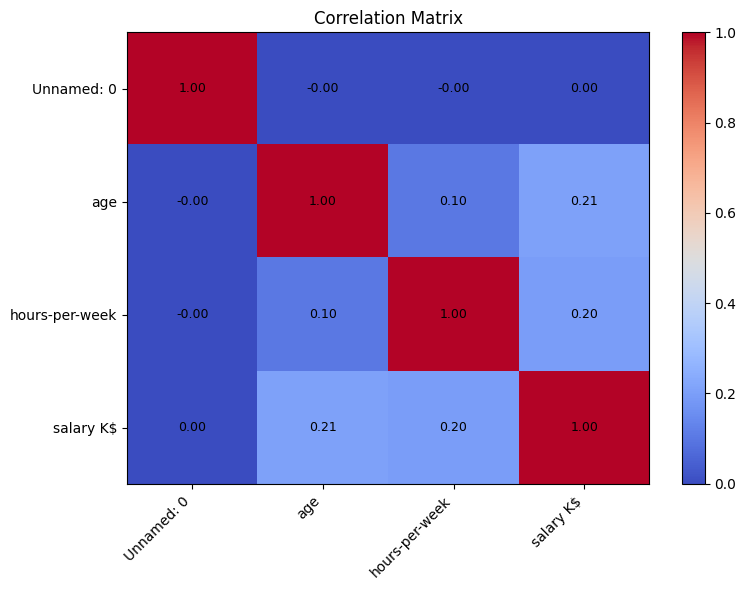

In [116]:
import matplotlib.pyplot as plt

corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr)), corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()